# 📊 Exploratory Data Analysis — Skrining Anemia Balita
Notebook ini digunakan untuk:
1. Memahami distribusi kelas dan ketidakseimbangan data
2. Inspeksi visual sampel gambar dan hasil crop ROI
3. Analisis distribusi fitur LBP, GLCM, dan Color Histogram
4. Visualisasi feature space dengan PCA
5. Heatmap korelasi antar fitur

> **Catatan:** Notebook ini bersifat READ-ONLY terhadap data — tidak melakukan split atau training.

## 1. Setup & Import

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')   # sembunyikan DeprecationWarning
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path

from config import CSV_PATH, CLASS_LABELS, INV_CLASS_LABELS, COL_SEVERITY, VIZ_DIR
from utils_data import load_metadata
from utils_preprocessing import preprocess_image
from extract_features import extract_sample_feature_vector, get_feature_names

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
VIZ_DIR.mkdir(parents=True, exist_ok=True)
print('✅ Import selesai')

✅ Import selesai


## 2. Load Data & Distribusi Kelas

In [2]:
df = load_metadata()
print(f'Total sampel valid: {len(df)}')
print(f'Distribusi kelas:')
print(df[COL_SEVERITY].value_counts().to_string())
df.head()

INFO | Membaca metadata dari: C:\Users\acer\Documents\anemia_screening\data\raw\Anemia_Data_Collection_Sheet.csv
INFO | Total sampel valid: 710
INFO | Distribusi kelas:
Severity
Non-Anemic    286
Moderate      232
Mild          144
Severe         48


Total sampel valid: 710
Distribusi kelas:
Severity
Non-Anemic    286
Moderate      232
Mild          144
Severe         48


,IMAGE_ID,image_path,Severity,label
0,Image_001,C:\Users\acer\Documents\anemia_screening\data\...,Moderate,1
1,Image_002,C:\Users\acer\Documents\anemia_screening\data\...,Moderate,1
2,Image_003,C:\Users\acer\Documents\anemia_screening\data\...,Non-Anemic,0
3,Image_004,C:\Users\acer\Documents\anemia_screening\data\...,Non-Anemic,0
4,Image_005,C:\Users\acer\Documents\anemia_screening\data\...,Moderate,1


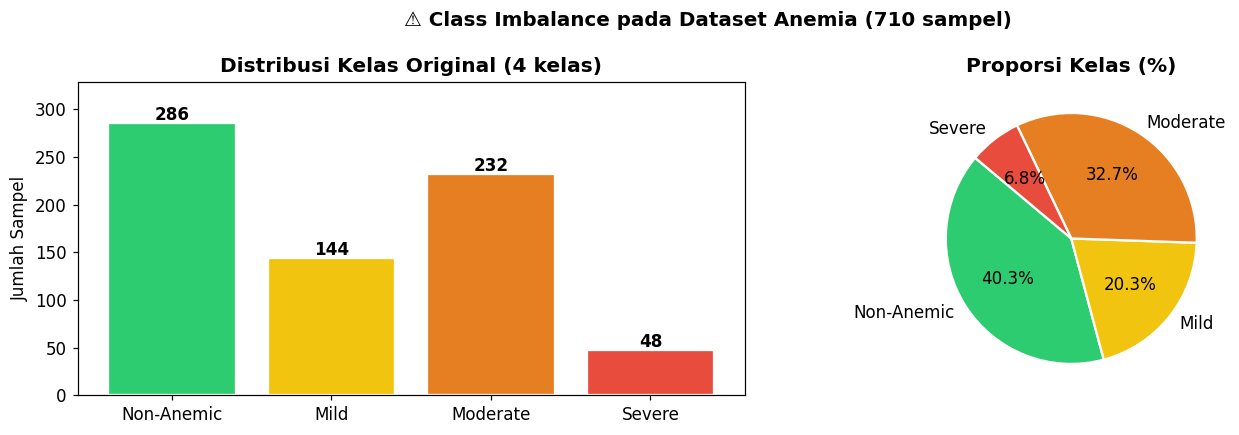

Imbalance ratio: 6.0x (mayoritas/minoritas)


In [3]:
class_order = ['Non-Anemic', 'Mild', 'Moderate', 'Severe']
colors4     = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
counts      = df[COL_SEVERITY].value_counts().reindex(class_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
bars = axes[0].bar(class_order, counts.values, color=colors4,
                   edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 3, str(v),
                 ha='center', fontweight='bold')
axes[0].set_title('Distribusi Kelas Original (4 kelas)', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=class_order, colors=colors4,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proporsi Kelas (%)', fontweight='bold')

plt.suptitle('⚠️ Class Imbalance pada Dataset Anemia (710 sampel)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'class_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'Imbalance ratio: {counts.max()/counts.min():.1f}x (mayoritas/minoritas)')

## 3. Inspeksi Visual Sampel Gambar per Kelas

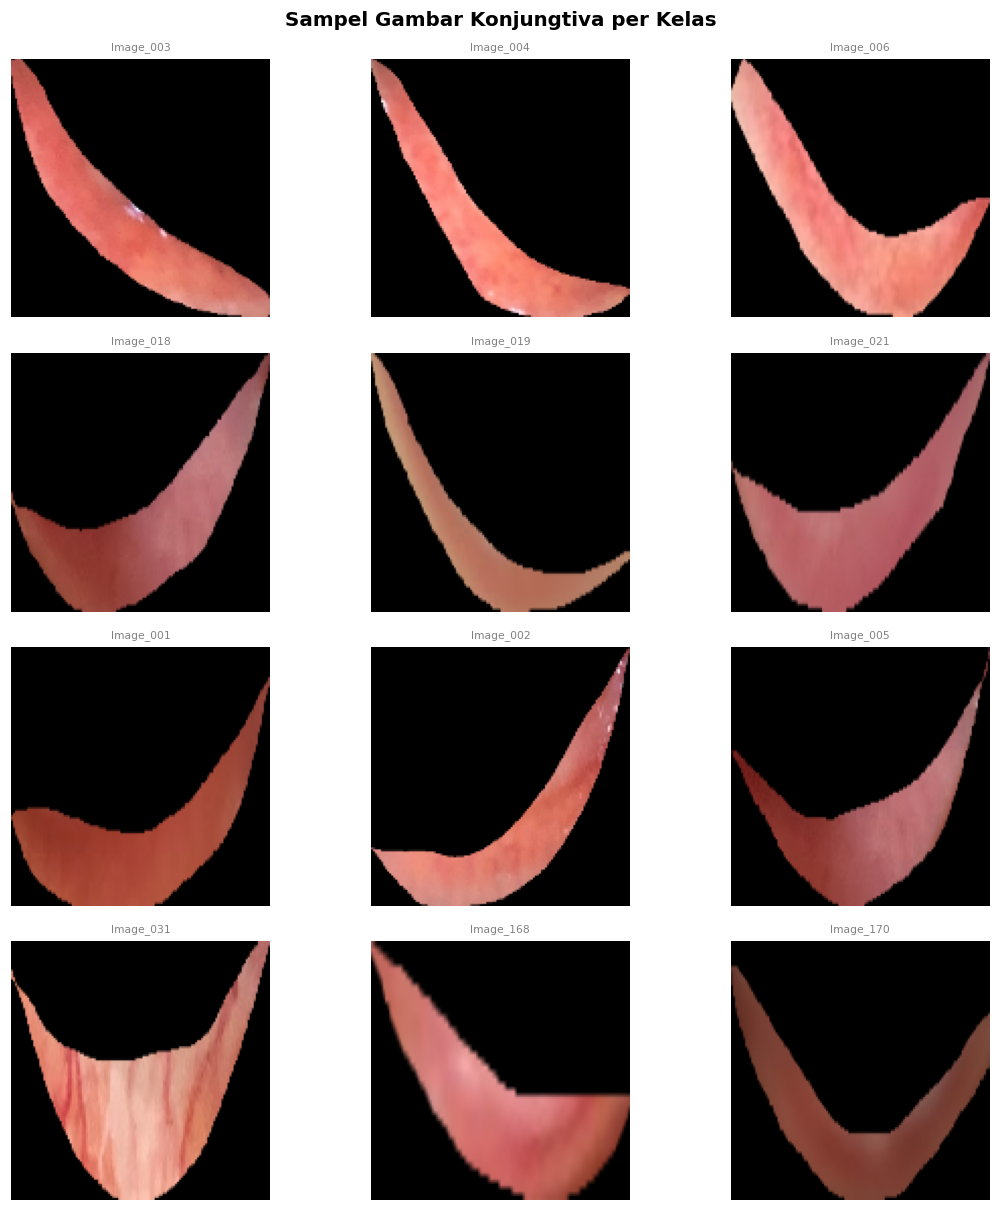

In [4]:
n_per_class = 3
fig, axes = plt.subplots(len(class_order), n_per_class,
                          figsize=(n_per_class * 3.5, len(class_order) * 2.8))

for row_idx, cls in enumerate(class_order):
    samples = df[df[COL_SEVERITY] == cls].head(n_per_class)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img = cv2.cvtColor(cv2.imread(str(row['image_path'])), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (128, 128))
        ax  = axes[row_idx][col_idx]
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold',
                          color=colors4[row_idx], rotation=90, labelpad=8)
        ax.set_title(row['IMAGE_ID'], fontsize=7, color='gray')

plt.suptitle('Sampel Gambar Konjungtiva per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'sample_images.png'), bbox_inches='tight', dpi=150)
plt.show()

## 4. Inspeksi Hasil Crop ROI Konjungtiva

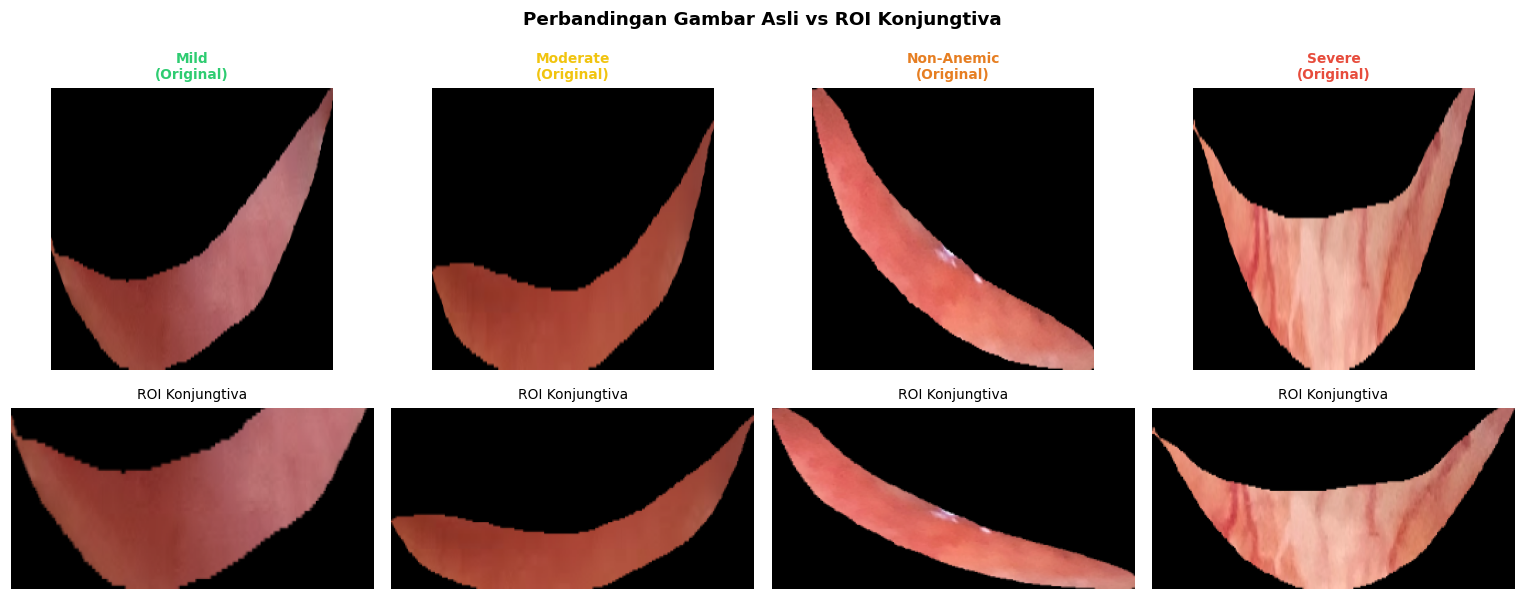

In [5]:
# Ambil satu sampel per kelas
sample_ids = df.groupby(COL_SEVERITY, group_keys=False).first().reset_index()

fig, axes = plt.subplots(2, len(class_order), figsize=(14, 6))

for col_idx, (_, row) in enumerate(sample_ids.iterrows()):
    img_orig = cv2.cvtColor(cv2.imread(str(row['image_path'])), cv2.COLOR_BGR2RGB)
    img_orig = cv2.resize(img_orig, (256, 256))
    roi      = preprocess_image(row['image_path'])

    axes[0][col_idx].imshow(img_orig)
    axes[0][col_idx].set_title(
        f"{row[COL_SEVERITY]}\n(Original)",
        fontsize=9, color=colors4[col_idx], fontweight='bold'
    )
    axes[0][col_idx].axis('off')

    if roi is not None:
        axes[1][col_idx].imshow(roi)   # ROI sudah RGB
    else:
        axes[1][col_idx].text(0.5, 0.5, 'ROI Gagal',
                               ha='center', va='center', color='red',
                               transform=axes[1][col_idx].transAxes)
    axes[1][col_idx].set_title('ROI Konjungtiva', fontsize=9)
    axes[1][col_idx].axis('off')

axes[0][0].set_ylabel('Gambar Asli', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('ROI Crop',    fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Gambar Asli vs ROI Konjungtiva', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'roi_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Ekstraksi Fitur Subsampel untuk EDA
Ambil maks 10 sampel per kelas agar proses cepat.

In [6]:
# Ambil subsampel per kelas
sample_df = (
    df.groupby(COL_SEVERITY, group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 10), random_state=42),
             include_groups=False)
      .reset_index(drop=True)
)
# Tambahkan kembali kolom Severity yang hilang setelah include_groups=False
sample_df = df.groupby(COL_SEVERITY).apply(
    lambda x: x.sample(min(len(x), 10), random_state=42)
).reset_index(drop=True)

print(f'Sampel EDA: {len(sample_df)} gambar')

X_list, y_list = [], []
for _, row in sample_df.iterrows():
    roi = preprocess_image(row['image_path'])
    if roi is not None:
        X_list.append(extract_sample_feature_vector(roi))
        y_list.append(row[COL_SEVERITY])

X_eda      = np.array(X_list)
y_eda      = np.array(y_list)
feat_names = get_feature_names()
df_feat    = pd.DataFrame(X_eda, columns=feat_names[:X_eda.shape[1]])
df_feat['Severity'] = y_eda

print(f'Feature matrix shape: {X_eda.shape}')
print(f'Nama fitur pertama  : {feat_names[:5]}')

Sampel EDA: 40 gambar


WARNING | Mask kosong. Menggunakan crop tengah sebagai fallback ROI.


Feature matrix shape: (40, 408)
Nama fitur pertama  : ['lbp_r1_bin0', 'lbp_r1_bin1', 'lbp_r1_bin2', 'lbp_r1_bin3', 'lbp_r1_bin4']


## 6. Distribusi Fitur GLCM per Kelas

Kolom GLCM yang digunakan: ['glcm_L_contrast_d1_a0', 'glcm_L_contrast_d1_a45', 'glcm_L_contrast_d1_a90', 'glcm_L_contrast_d1_a135', 'glcm_L_contrast_d2_a0', 'glcm_L_contrast_d2_a45']


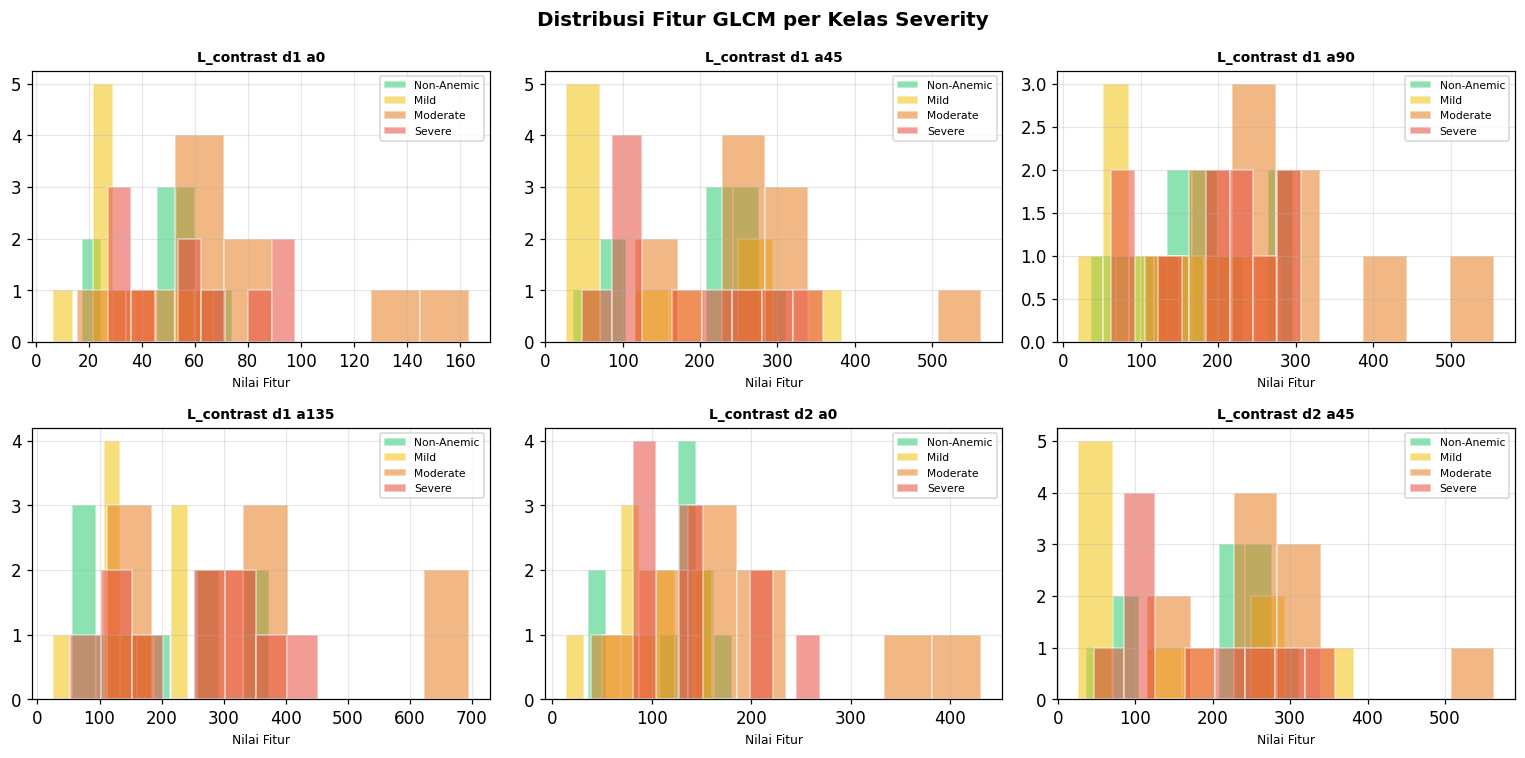

In [7]:
# Cari nama kolom GLCM yang benar dari feat_names
glcm_cols = [c for c in feat_names if 'glcm' in c][:6]
print(f'Kolom GLCM yang digunakan: {glcm_cols}')

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes_flat = axes.ravel()

for i, col in enumerate(glcm_cols):
    if col not in df_feat.columns:
        axes_flat[i].set_visible(False)
        continue
    for cls, color in zip(class_order, colors4):
        data = df_feat[df_feat['Severity'] == cls][col].dropna()
        if len(data) > 0:
            axes_flat[i].hist(data, bins=8, alpha=0.55, label=cls,
                              color=color, edgecolor='white')
    short_name = col.replace('glcm_', '').replace('_d', ' d').replace('_a', ' a')
    axes_flat[i].set_title(short_name, fontsize=9, fontweight='bold')
    axes_flat[i].set_xlabel('Nilai Fitur', fontsize=8)
    axes_flat[i].legend(fontsize=7)
    axes_flat[i].grid(alpha=0.3)

plt.suptitle('Distribusi Fitur GLCM per Kelas Severity', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'glcm_feature_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()

## 7. Distribusi Fitur Warna (Color Moments) per Kelas

Kolom moment: ['moment_Lab_L_mean', 'moment_Lab_L_std', 'moment_Lab_L_skew', 'moment_Lab_a_mean', 'moment_Lab_a_std', 'moment_Lab_a_skew']


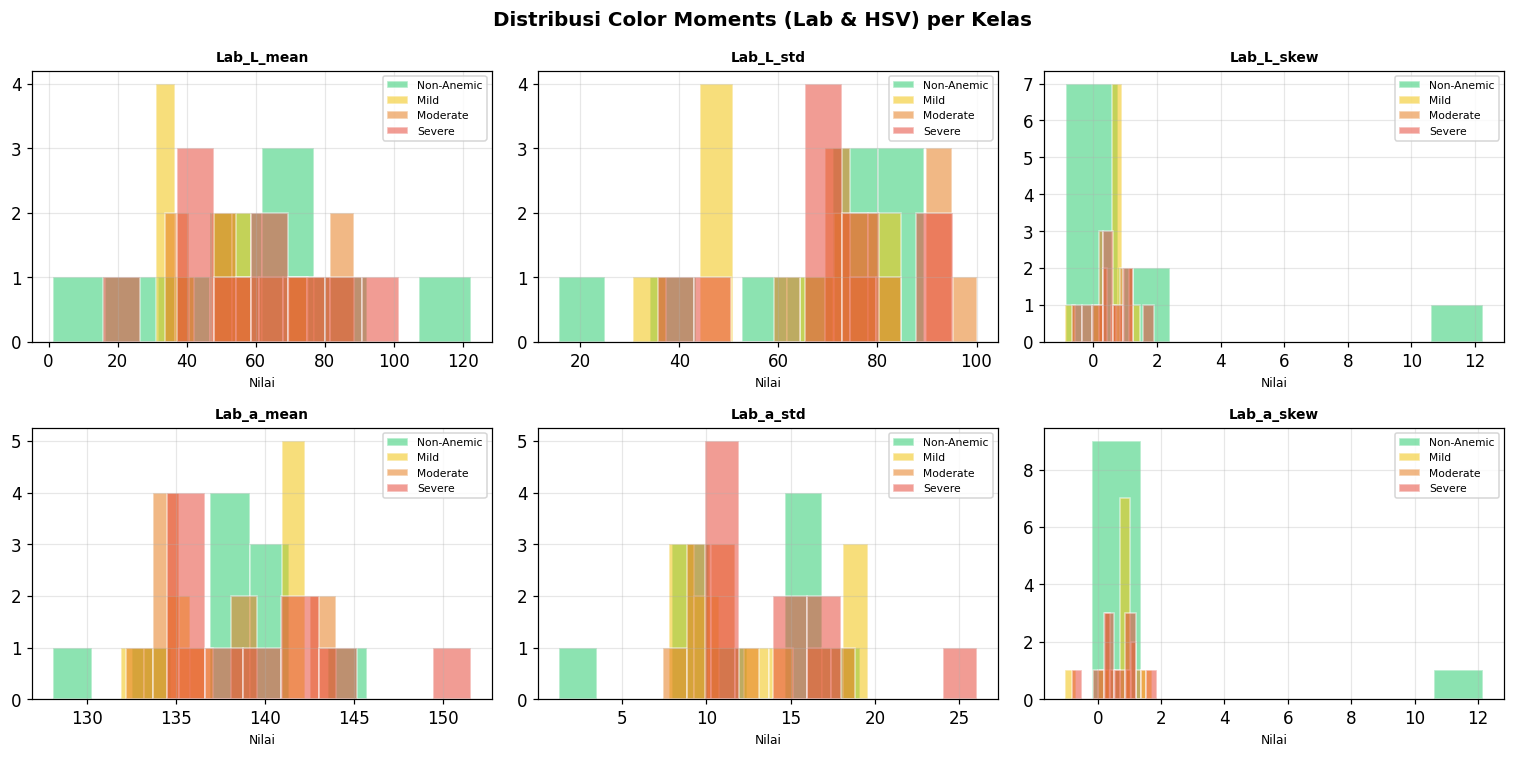

In [8]:
# Color moments — mean channel a* (proxy hemoglobin) sangat penting
moment_cols = [c for c in feat_names if 'moment' in c][:6]
print(f'Kolom moment: {moment_cols}')

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes_flat = axes.ravel()

for i, col in enumerate(moment_cols):
    if col not in df_feat.columns:
        continue
    for cls, color in zip(class_order, colors4):
        data = df_feat[df_feat['Severity'] == cls][col].dropna()
        if len(data) > 0:
            axes_flat[i].hist(data, bins=8, alpha=0.55, label=cls,
                              color=color, edgecolor='white')
    axes_flat[i].set_title(col.replace('moment_', ''), fontsize=9, fontweight='bold')
    axes_flat[i].set_xlabel('Nilai', fontsize=8)
    axes_flat[i].legend(fontsize=7)
    axes_flat[i].grid(alpha=0.3)

plt.suptitle('Distribusi Color Moments (Lab & HSV) per Kelas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'color_moments_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()

## 8. PCA Feature Space (2D)

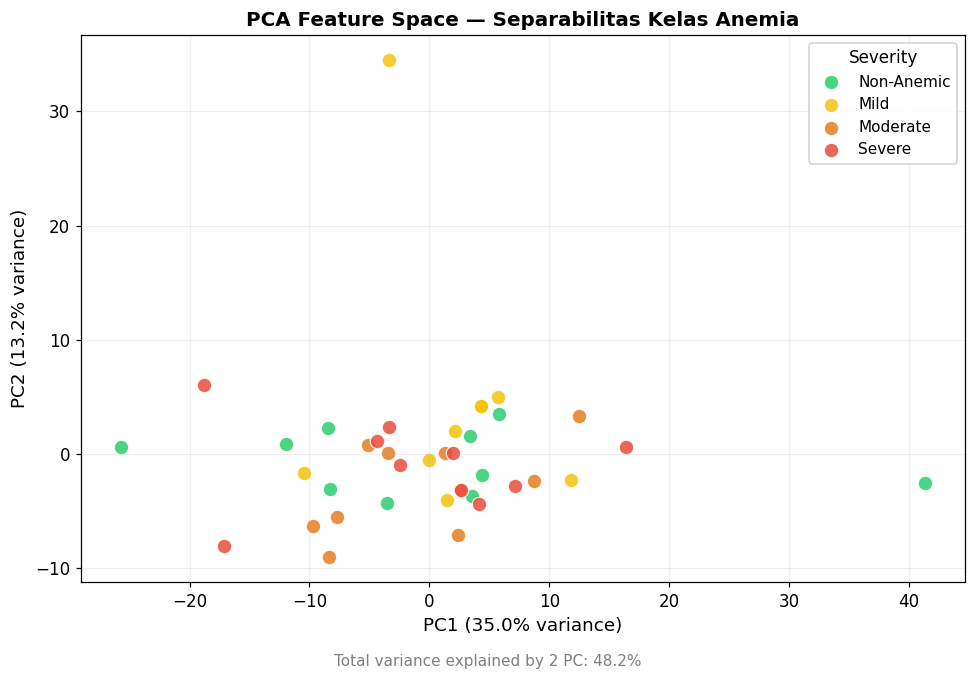

Total variance explained by 2 PC: 48.2%


In [9]:
scaler_eda = StandardScaler()
X_scaled   = scaler_eda.fit_transform(X_eda)

pca2       = PCA(n_components=2, random_state=42)
X_pca      = pca2.fit_transform(X_scaled)
explained  = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
for cls, color in zip(class_order, colors4):
    mask = y_eda == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=cls, color=color, s=90, alpha=0.85,
               edgecolors='white', linewidth=0.8)

ax.set_xlabel(f'PC1 ({explained[0]:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]:.1f}% variance)', fontsize=12)
ax.set_title('PCA Feature Space — Separabilitas Kelas Anemia', fontweight='bold', fontsize=13)
ax.legend(title='Severity', framealpha=0.9, fontsize=10)
ax.grid(True, alpha=0.2)
plt.figtext(0.5, -0.02, f'Total variance explained by 2 PC: {sum(explained):.1f}%',
            ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'pca_feature_space.png'), bbox_inches='tight', dpi=150)
plt.show()
print(f'Total variance explained by 2 PC: {sum(explained):.1f}%')

## 9. Heatmap Korelasi Fitur

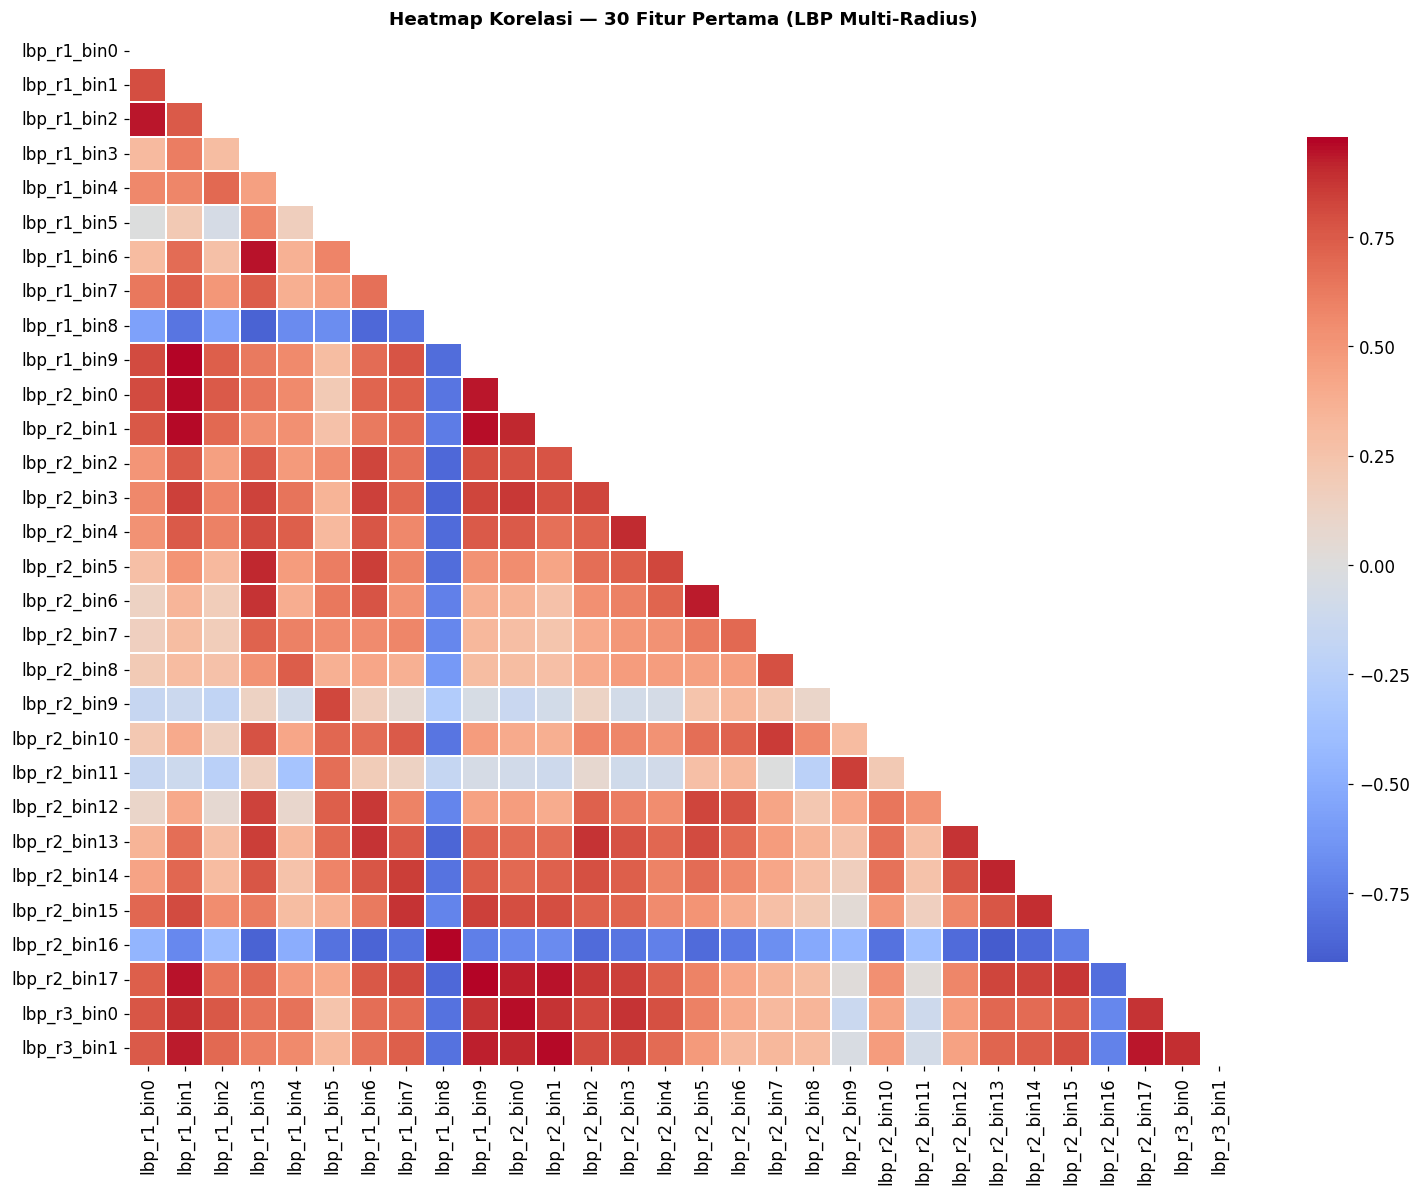

In [10]:
# Ambil 30 fitur pertama agar heatmap terbaca
corr_matrix = df_feat.drop(columns='Severity').iloc[:, :30].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Heatmap Korelasi — 30 Fitur Pertama (LBP Multi-Radius)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(str(VIZ_DIR / 'feature_correlation.png'), bbox_inches='tight', dpi=150)
plt.show()

## 10. Ringkasan EDA

In [11]:
print('=' * 55)
print('RINGKASAN EXPLORATORY DATA ANALYSIS')
print('=' * 55)
print(f'Total sampel            : {len(df)}')
print(f'Kelas mayoritas         : {counts.idxmax()} ({counts.max()} sampel)')
print(f'Kelas minoritas         : {counts.idxmin()} ({counts.min()} sampel)')
print(f'Imbalance ratio         : {counts.max()/counts.min():.1f}x')
print(f'Dimensi vektor fitur    : {X_eda.shape[1]}')
print(f'  - LBP multi-radius    : 78 dim')
print(f'  - GLCM (L + a*)       : 144 dim')
print(f'  - Color Histogram     : 192 dim')
print(f'  - Color Moments       : 18 dim')
print(f'PCA variance (2 PC)     : {sum(explained):.1f}%')
print('=' * 55)
print(f'Visualisasi tersimpan di: outputs/visualizations/')

RINGKASAN EXPLORATORY DATA ANALYSIS
Total sampel            : 710
Kelas mayoritas         : Non-Anemic (286 sampel)
Kelas minoritas         : Severe (48 sampel)
Imbalance ratio         : 6.0x
Dimensi vektor fitur    : 408
  - LBP multi-radius    : 78 dim
  - GLCM (L + a*)       : 144 dim
  - Color Histogram     : 192 dim
  - Color Moments       : 18 dim
PCA variance (2 PC)     : 48.2%
Visualisasi tersimpan di: outputs/visualizations/
